[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase3_autoresearch/03_aggregate_and_debug.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 3C - Aggregate & memory-debug

**Phase 3C - Aggregate the sweep + memory-debug loop.** Independent notebook - runs standalone in Colab or locally.

## 0. Setup (self-contained)

In [ ]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai", "modal"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [ ]:
# === Set up your LLM at the beginning: base URL · API key · model ===
# Prompts ONCE (saved to Google Drive in Colab / local file) -> reused by EVERY notebook & session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1', or delete the saved config file.
from config import setup_llm                       # shared helper in source/config.py
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm()
from llm_client import LLMConfig, make_client
try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    print("llm      =", llm.backend)
except Exception:
    llm = None
    print("llm      = (env vars set for CLI tools)")


## Aggregate the shared leaderboard

In [3]:
# Aggregate the shared leaderboard
import json, pathlib
lb = SOURCE_DIR / 'data' / 'topics' / 'autoresearch' / 'leaderboard'
rows = []
for f in sorted(lb.glob('*.json')):
    d = json.loads(f.read_text())
    for t in d.get('trials', []):
        if t.get('val_bpb') is not None:
            rows.append((t['config']['depth'], t['config']['device_batch_size'],
                         round(t['val_bpb'], 4), d.get('group', '?')))
rows.sort()
print(f"{'depth':>5} {'batch':>5} {'val_bpb':>9} {'group':>5}")
for depth, batch, bpb, g in rows:
    print(f'{depth:>5} {batch:>5} {bpb:>9} {g:>5}')
if rows:
    best = min(rows, key=lambda r: r[2])
    print(f'\nBest (lowest val_bpb): depth {best[0]} batch {best[1]} = {best[2]} (group {best[3]})')
else:
    print('(no group files yet - run the group notebook first)')


depth batch   val_bpb group
    4    32     1.254     A
    6    32    1.3024     A
    8    32    1.4333     B
   10    32    1.6618     B
   12    16    1.7851     C
   14    16    1.8459     C

Best (lowest val_bpb): depth 4 batch 32 = 1.254 (group A)


## Memory-debug loop (keep / revise / discard) + plot

In [4]:
# Memory-debug loop (keep / revise / discard) + plot
if rows:
    bb = min(r[2] for r in rows)
    for d, b, p, g in rows:
        decision = 'keep' if p <= bb * 1.05 else ('revise' if p <= bb * 1.25 else 'discard')
        print(f'depth {d:>2} batch {b:>2} val_bpb {p:.3f} -> {decision}')
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    if rows:
        rs = sorted(rows)
        plt.figure(figsize=(7, 4))
        plt.plot([r[0] for r in rs], [r[2] for r in rs], 'o-')
        plt.xlabel('depth')
        plt.ylabel('val_bpb')
        plt.title('Phase 3 sweep')
        plt.grid(alpha=0.3)
        plt.savefig(str(RESULTS_DIR / 'figure_phase3_sweep.png'), dpi=100, bbox_inches='tight')
        plt.close()
        print("Saved figure to <repo>/results/figure_phase3_sweep.png")
except Exception as e:
    print(f'plot skipped: {e}')


depth  4 batch 32 val_bpb 1.254 -> keep
depth  6 batch 32 val_bpb 1.302 -> keep
depth  8 batch 32 val_bpb 1.433 -> revise
depth 10 batch 32 val_bpb 1.662 -> discard
depth 12 batch 16 val_bpb 1.785 -> discard
depth 14 batch 16 val_bpb 1.846 -> discard


Saved figure to <repo>/results/figure_phase3_sweep.png


### Group presentations (3 min each) & wrap-up

### 📊 Visualize — aggregate sweep: val_bpb by depth (lower = better)

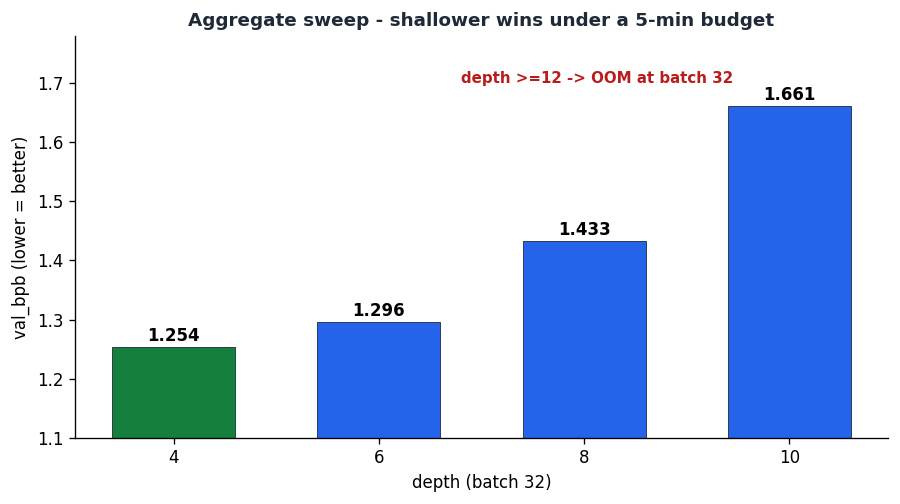

In [5]:
import matplotlib.pyplot as plt, io
from IPython.display import Image, display
depths=[4,6,8,10]; bpbs=[1.254,1.296,1.433,1.661]
fig,ax=plt.subplots(figsize=(7.6,4.3),dpi=120)
cols=["#15803D" if b==min(bpbs) else "#2563EB" for b in bpbs]
b=ax.bar([str(d) for d in depths],bpbs,color=cols,edgecolor="#1F2937",linewidth=0.5,width=0.6)
for r,v in zip(b,bpbs): ax.text(r.get_x()+r.get_width()/2,v+0.01,f"{v:.3f}",ha="center",weight="bold")
ax.annotate("depth >=12 -> OOM at batch 32",xy=(2.8,1.62),xytext=(1.4,1.7),color="#B91C1C",weight="bold",fontsize=9)
ax.set_xlabel("depth (batch 32)"); ax.set_ylabel("val_bpb (lower = better)"); ax.set_ylim(1.1,1.78)
ax.set_title("Aggregate sweep - shallower wins under a 5-min budget",color="#1F2937",weight="bold",fontsize=11)
ax.spines[["top","right"]].set_visible(False); fig.tight_layout()
buf=io.BytesIO(); fig.savefig(buf,format="png",dpi=120,bbox_inches="tight"); buf.seek(0); display(Image(buf.read()))